Processed data is stored in pkl file<br>
Load data and fit with PyMC<br>
Pt100 KOH CO oxidation<br>

In [2]:
from setup import *

# ER 2 Lateral

In [ ]:
with pm.Model() as ER_2_lateral:
    '''
    1. CO + * <-> CO* (QEA Frumkin)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA Frumkin)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE
    z_CO = pm.TruncatedNormal('z_CO', lower=0, mu=0.2, sigma=0.2)
    z_OH = pt.as_tensor_variable(0.0)
    z_cross = pt.as_tensor_variable(0.0) 

    # Thermodynamics 
    deltaG1_base = deltaG1_0
    deltaG4_base = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1_base = -deltaG1_base/(kb_eV*T)
    log_K4_base = -deltaG4_base/(kb_eV*T)
    log_k2_base = np.log(kb_J*T/h) - Gact2/(kb_eV*T) 

    # Initial guess: No interactions
    term_CO_base = log_K1_base + np.log(P_CO_in)
    term_OH_base = log_K4_base + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO_base)
    log_theta_init = -pt.logsumexp(pt.stack([zeros, term_CO_base, term_OH_base]), axis=0)
    theta_CO_guess = pt.exp(term_CO_base + log_theta_init)
    theta_OH_guess = pt.exp(term_OH_base + log_theta_init)

    # Iterative solver setup 
    n_iter_steps = 24
    damp_array = pt.as_tensor_variable(np.maximum(0.6 * (0.80 ** np.arange(n_iter_steps)), 0.05))
    def frumkin_step(damp, theta_CO_prev, theta_OH_prev, term_CO_base, term_OH_base, z_CO, z_OH, z_cross, kb_T, zeros): 
        penalty_CO = (z_CO * theta_CO_prev + z_cross * theta_OH_prev) / kb_T 
        penalty_OH = (z_OH * theta_OH_prev + z_cross * theta_CO_prev) / kb_T 
        term_CO_iter = term_CO_base - penalty_CO
        term_OH_iter = term_OH_base - penalty_OH
        log_theta_iter = -pt.logsumexp(pt.stack([zeros, term_CO_iter, term_OH_iter]), axis=0)
        theta_CO_calc = pt.exp(term_CO_iter + log_theta_iter)
        theta_OH_calc = pt.exp(term_OH_iter + log_theta_iter)
        theta_CO_new = damp * theta_CO_calc + (1.0 - damp) * theta_CO_prev
        theta_OH_new = damp * theta_OH_calc + (1.0 - damp) * theta_OH_prev
        return theta_CO_new, theta_OH_new
    
    theta_CO_seq, theta_OH_seq = pytensor.scan(fn=frumkin_step, sequences=[damp_array], outputs_info=[theta_CO_guess, theta_OH_guess],
        non_sequences=[term_CO_base, term_OH_base, z_CO, z_OH, z_cross, kb_eV * T, zeros], n_steps=n_iter_steps, return_updates=False) 

    theta_CO_final = theta_CO_seq[-1]
    theta_OH_final = theta_OH_seq[-1]
    CO_error = pt.max(pt.abs(theta_CO_seq[-1] - theta_CO_seq[-2])); pm.Deterministic('CO_converge_error', CO_error)
    OH_error = pt.max(pt.abs(theta_OH_seq[-1] - theta_OH_seq[-2])); pm.Deterministic('OH_converge_error', OH_error)

    penalty_CO_final = (z_CO * theta_CO_final + z_cross * theta_OH_final) / (kb_eV * T)
    penalty_OH_final = (z_OH * theta_OH_final + z_cross * theta_CO_final) / (kb_eV * T) 

    term_CO_final = term_CO_base - penalty_CO_final 
    term_OH_final = term_OH_base - penalty_OH_final 
    log_theta_final = -pt.logsumexp(pt.stack([zeros, term_CO_final, term_OH_final]), axis=0)
    log_theta_CO = term_CO_final + log_theta_final
    log_theta_OH = term_OH_final + log_theta_final

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_k2_final = log_k2_base + 0.5 * penalty_CO_final 
    log_rate_model = log_k2_final + log_theta_CO + np.log(C_KOH_in) 
    log_rate = observables(log_rate_model) 

trace_ER_2_lateral, loo_ER_2_lateral = fit_and_evaluate(ER_2_lateral)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,897,0,0.05,31
,728,0,0.08,127
,495,0,0.06,287
,3000,0,0.33,31


                    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0         -0.152  0.004  -0.159   -0.145      0.000    0.000    2162.0    2240.0   1.00
deltaG4_0         -0.545  0.080  -0.688   -0.399      0.004    0.002     461.0     845.0   1.01
Gact2_0            0.705  0.004   0.698    0.714      0.000    0.000     571.0    1036.0   1.01
z_OH               0.456  0.076   0.317    0.591      0.003    0.002     458.0     890.0   1.01
beta_2             0.402  0.008   0.386    0.417      0.000    0.000    1920.0    2115.0   1.00
z_CO               0.044  0.025   0.000    0.087      0.001    0.000    1338.0     909.0   1.00
CO_converge_error  0.000  0.000   0.000    0.000      0.000    0.000    1074.0     917.0   1.00
OH_converge_error  0.000  0.000   0.000    0.000      0.000    0.000    1904.0    2090.0   1.00


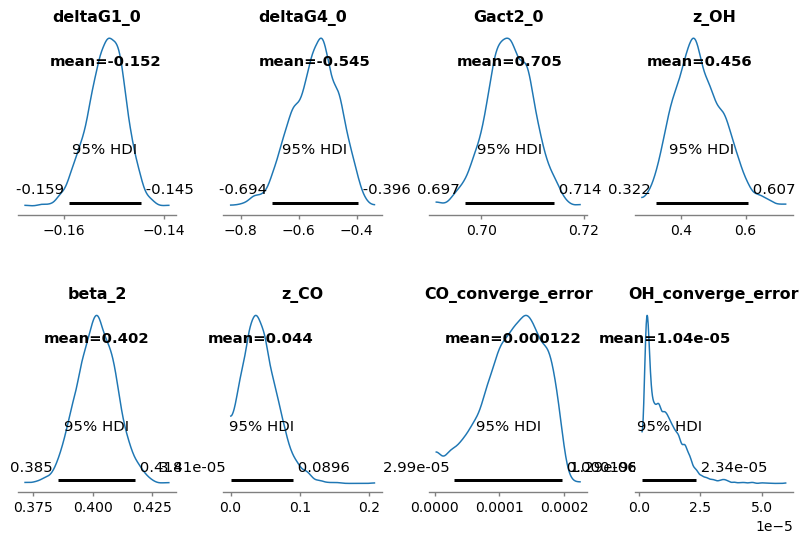

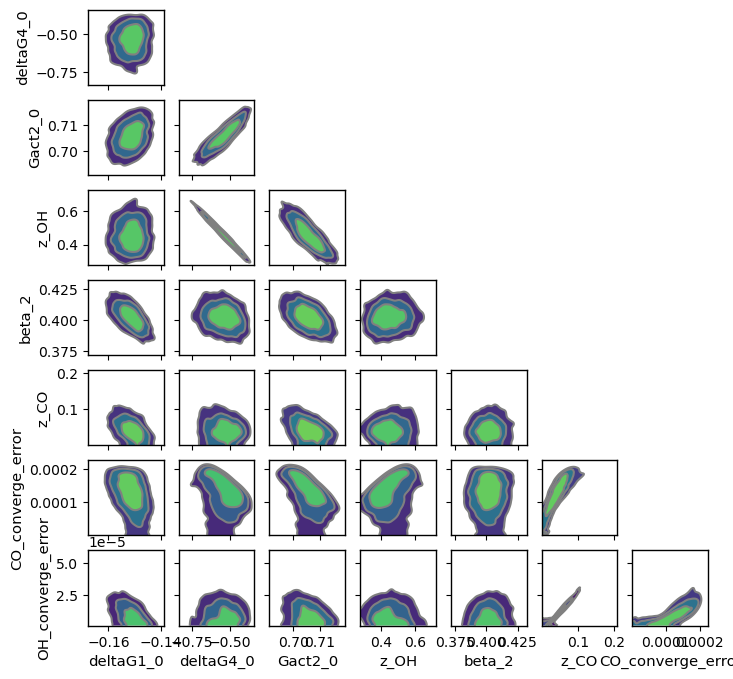

Sampling: [rate]


rate: 0.828


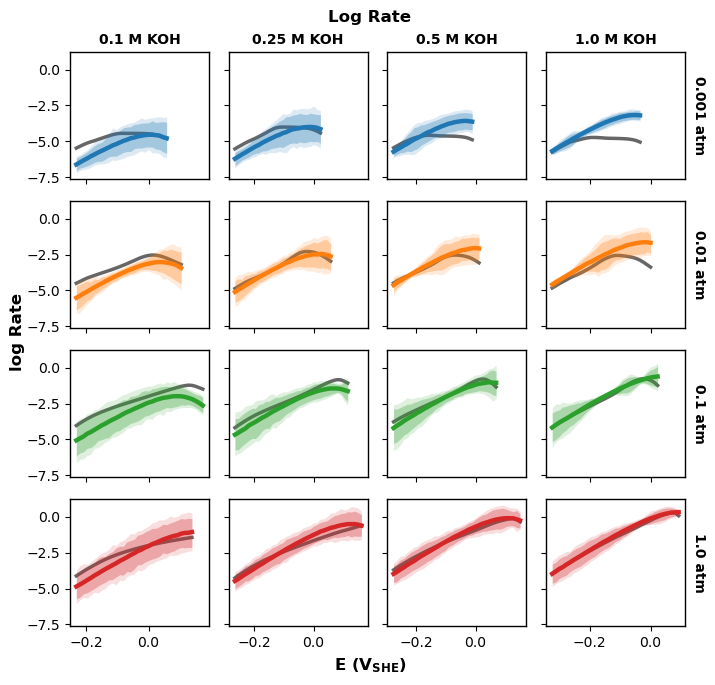

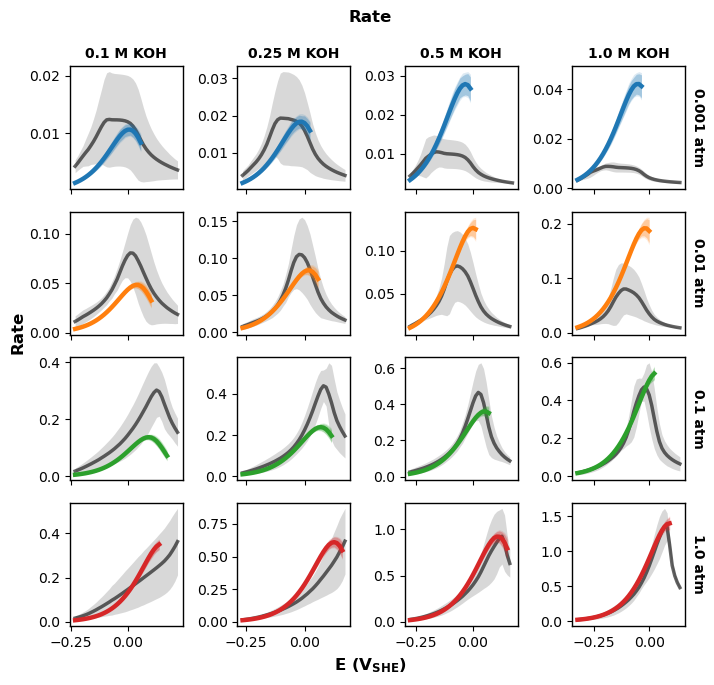

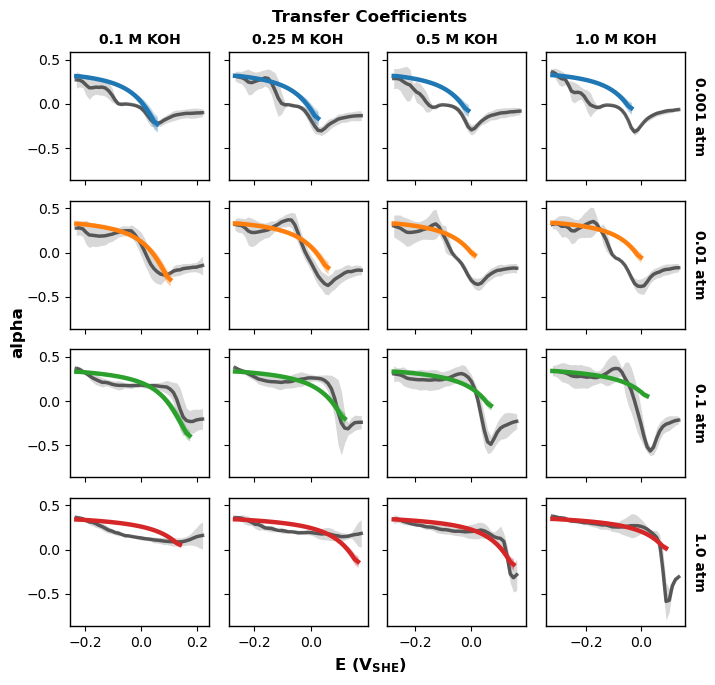

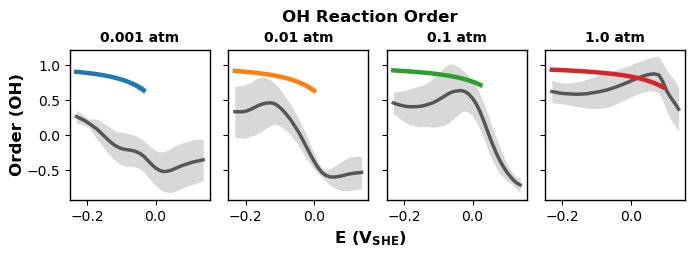

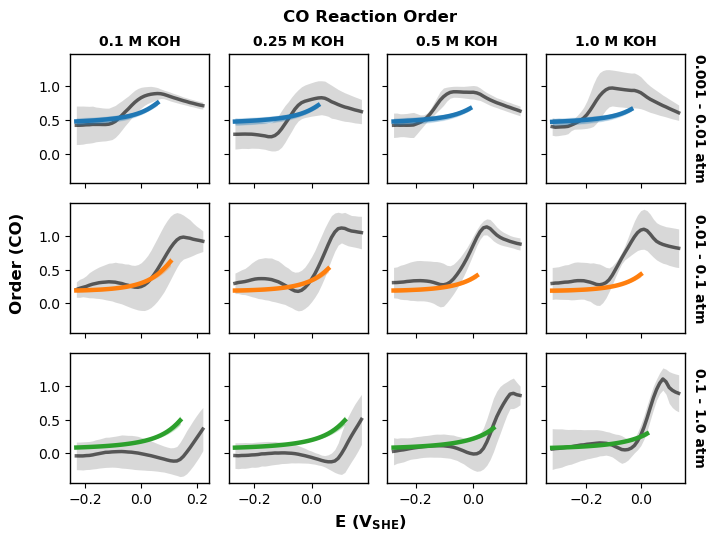

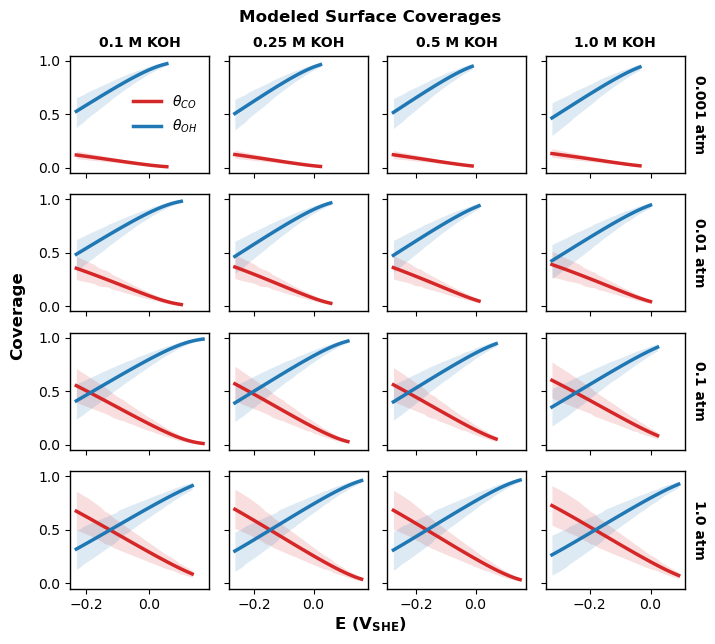

In [6]:
ppc_ER_2_lateral = plot_posteriors(trace_ER_2_lateral, ER_2_lateral, plot_target)
plot_model_fits(trace_ER_2_lateral, ppc_ER_2_lateral); plot_coverages(trace_ER_2_lateral)

# ER 1 2 Lateral

In [ ]:
with pm.Model() as ER_1_2_lateral:
    '''
    1. CO + * <-> CO* (Collision Theory with Frumkin & BEP)
    2. CO* + OH- -> COOH* + (e-) (SSA with BEP)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA Frumkin)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.475, sigma=0.1) 
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.063, sigma=0.1) # at 0V_SHE
    beta_2 = pm.Normal('beta_2', mu=0.345, sigma=0.05)
    Gact1_0 = pm.TruncatedNormal('Gact1_0', mu=0.311, sigma=0.05, lower=0)
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.739, sigma=0.05, lower=0) # at 0V_SHE
    
    z_CO = pm.TruncatedNormal('z_CO', lower=0, mu=0.2, sigma=0.2)
    z_OH = pt.as_tensor_variable(0.0)
    z_cross = pt.as_tensor_variable(0.0)

    bep_alpha_1 = 0.0
    bep_alpha_2 = 0.65

    # Thermodynamics 
    deltaG1_base = deltaG1_0
    deltaG4_base = deltaG4_0 - E_in
    Gact1_base = Gact1_0
    Gact2_base = Gact2_0 - beta_2*E_in
    
    log_K1_base = -deltaG1_base/(kb_eV*T)
    log_K4_base = -deltaG4_base/(kb_eV*T)
    log_k1_base = log_k1_smol - Gact1_base/(kb_eV*T)
    log_k2_base = np.log(kb_J*T/h) - Gact2_base/(kb_eV*T)

    # Initial guess: No interactions
    term_CO_base = log_k1_base + np.log(P_CO_in) - pt.logaddexp(log_k1_base - log_K1_base, log_k2_base + np.log(C_KOH_in))
    term_OH_base = log_K4_base + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO_base)
    log_theta_init = -pt.logsumexp(pt.stack([zeros, term_CO_base, term_OH_base]), axis=0)
    theta_CO_guess = pt.exp(term_CO_base + log_theta_init)
    theta_OH_guess = pt.exp(term_OH_base + log_theta_init)

    # Iterative solver setup 
    n_iter_steps = 24
    damp_array = pt.as_tensor_variable(np.maximum(0.6 * (0.80 ** np.arange(n_iter_steps)), 0.05))
    
    def frumkin_step(damp, theta_CO_prev, theta_OH_prev, log_k1_base, log_k2_base, log_K1_base, log_K4_base, z_CO, z_OH, z_cross, kb_T, zeros, P_CO_in, C_KOH_in):
        penalty_CO = (z_CO * theta_CO_prev + z_cross * theta_OH_prev) / kb_T
        penalty_OH = (z_OH * theta_OH_prev + z_cross * theta_CO_prev) / kb_T 
        
        log_K1_iter = log_K1_base - penalty_CO
        log_K4_iter = log_K4_base - penalty_OH
        
        log_k1_iter = log_k1_base - bep_alpha_1 * penalty_CO # BEP kinetic penalty on adsorption 
        log_k2_iter = log_k2_base + bep_alpha_2 * penalty_CO # BEP kinetic bonus on reaction 
        
        term_CO_iter = log_k1_iter + np.log(P_CO_in) - pt.logaddexp(log_k1_iter - log_K1_iter, log_k2_iter + np.log(C_KOH_in)) 
        term_OH_iter = log_K4_iter + np.log(C_KOH_in)
        
        log_theta_iter = -pt.logsumexp(pt.stack([zeros, term_CO_iter, term_OH_iter]), axis=0)
        theta_CO_calc = pt.exp(term_CO_iter + log_theta_iter)
        theta_OH_calc = pt.exp(term_OH_iter + log_theta_iter)
        
        theta_CO_new = damp * theta_CO_calc + (1.0 - damp) * theta_CO_prev
        theta_OH_new = damp * theta_OH_calc + (1.0 - damp) * theta_OH_prev
        return theta_CO_new, theta_OH_new

    theta_CO_seq, theta_OH_seq = pytensor.scan(fn=frumkin_step, sequences=[damp_array], outputs_info=[theta_CO_guess, theta_OH_guess],
        non_sequences=[log_k1_base, log_k2_base, log_K1_base, log_K4_base, z_CO, z_OH, z_cross, kb_eV * T, zeros, P_CO_in, C_KOH_in], n_steps=n_iter_steps, return_updates=False)

    theta_CO_final = theta_CO_seq[-1]
    theta_OH_final = theta_OH_seq[-1]
    CO_error = pt.max(pt.abs(theta_CO_seq[-1] - theta_CO_seq[-2])); pm.Deterministic('CO_converge_error', CO_error)
    OH_error = pt.max(pt.abs(theta_OH_seq[-1] - theta_OH_seq[-2])); pm.Deterministic('OH_converge_error', OH_error)

    # Final Evaluation
    penalty_CO_final = (z_CO * theta_CO_final + z_cross * theta_OH_final) / (kb_eV * T) 
    penalty_OH_final = (z_OH * theta_OH_final + z_cross * theta_CO_final) / (kb_eV * T) 
    
    log_K1_final = log_K1_base - penalty_CO_final
    log_K4_final = log_K4_base - penalty_OH_final
    log_k1_final = log_k1_base - bep_alpha_1 * penalty_CO_final # BEP kinetic penalty 
    log_k2_final = log_k2_base + bep_alpha_2 * penalty_CO_final # BEP kinetic bonus 

    term_CO_final = log_k1_final + np.log(P_CO_in) - pt.logaddexp(log_k1_final - log_K1_final, log_k2_final + np.log(C_KOH_in))
    term_OH_final = log_K4_final + np.log(C_KOH_in)
    
    log_theta_final = -pt.logsumexp(pt.stack([zeros, term_CO_final, term_OH_final]), axis=0)
    log_theta_CO = term_CO_final + log_theta_final
    log_theta_OH = term_OH_final + log_theta_final

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_model = log_k2_final + np.log(C_KOH_in) + log_theta_CO
    log_rate = observables(log_rate_model) 

trace_ER_1_2_lateral, loo_ER_1_2_lateral = fit_and_evaluate(ER_1_2_lateral, target_accept=0.99)

In [ ]:
ppc_ER_1_2_lateral = plot_posteriors(trace_ER_1_2_lateral, ER_1_2_lateral, plot_target)
plot_model_fits(trace_ER_1_2_lateral, ppc_ER_1_2_lateral); plot_coverages(trace_ER_1_2_lateral)

# ER LH 2 Lateral

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.19,63
,3000,0,0.22,15
,3000,0,0.23,63
,3000,0,0.21,63


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -476.26    35.29
p_loo       22.50        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      494  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



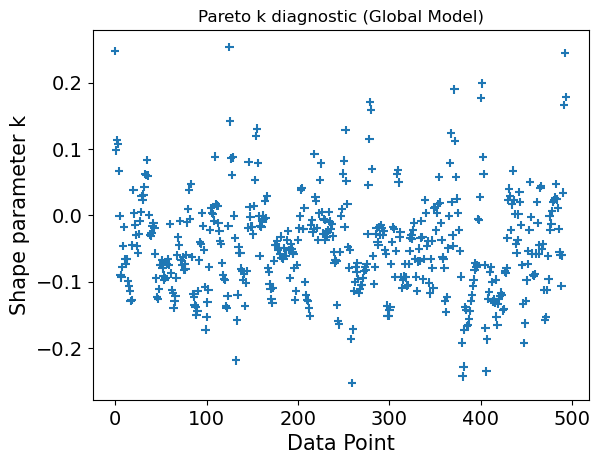

In [7]:
with pm.Model() as ER_LH_2_lateral:
    '''
    1. CO + * <-> CO* (QEA Frumkin)
    2a. CO* + OH- -> COOH* + (e-) (RDS)
    2b. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA Frumkin)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.2, sigma=0.2, upper=0)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=10.0, beta=30.0)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.75, sigma=0.02) # at 0V_SHE
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.75, sigma=0.05) 
    z_CO = pm.TruncatedNormal('z_CO', lower=0, mu=0.2, sigma=0.2)
    # z_OH = pm.Normal('z_OH', mu=0.4, sigma=0.2)
    z_OH = 0.0

    # Thermodynamics
    deltaG1_base = deltaG1_0
    deltaG4_base = deltaG4_0 - E_in
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    log_K1_base = -deltaG1_base/(kb_eV*T)
    log_K4_base = -deltaG4_base/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    # Initial guess: No interactions
    term_CO_base = log_K1_base + np.log(P_CO_in)
    term_OH_base = log_K4_base + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO_base)
    log_theta_init = -pt.logsumexp(pt.stack([zeros, term_CO_base, term_OH_base]), axis=0)
    theta_CO_guess = pt.exp(term_CO_base + log_theta_init)
    theta_OH_guess = pt.exp(term_OH_base + log_theta_init)
    
    # Iterative solver setup
    n_iter_steps = 15
    damp_array = pt.as_tensor_variable(np.maximum(0.6 * (0.80 ** np.arange(n_iter_steps)), 0.05))
    def frumkin_step(damp, theta_CO_prev, theta_OH_prev, term_CO_base, term_OH_base, z_CO, z_OH, kb_T, zeros):
        penalty_CO = z_CO * theta_CO_prev / kb_T
        penalty_OH = z_OH * theta_OH_prev / kb_T
        term_CO_iter = term_CO_base - penalty_CO
        term_OH_iter = term_OH_base - penalty_OH
        log_theta_iter = -pt.logsumexp(pt.stack([zeros, term_CO_iter, term_OH_iter]), axis=0)
        theta_CO_calc = pt.exp(term_CO_iter + log_theta_iter)
        theta_OH_calc = pt.exp(term_OH_iter + log_theta_iter)
        theta_CO_new = damp * theta_CO_calc + (1.0 - damp) * theta_CO_prev
        theta_OH_new = damp * theta_OH_calc + (1.0 - damp) * theta_OH_prev
        return theta_CO_new, theta_OH_new

    theta_CO_seq, theta_OH_seq = pytensor.scan(fn=frumkin_step, sequences=[damp_array], outputs_info=[theta_CO_guess, theta_OH_guess],
        non_sequences=[term_CO_base, term_OH_base, z_CO, z_OH, kb_eV * T, zeros], n_steps=n_iter_steps, return_updates=False)

    theta_CO_final = theta_CO_seq[-1]
    theta_OH_final = theta_OH_seq[-1]
    CO_error = pt.max(pt.abs(theta_CO_seq[-1] - theta_CO_seq[-2])); pm.Deterministic('CO_converge_error', CO_error)
    OH_error = pt.max(pt.abs(theta_OH_seq[-1] - theta_OH_seq[-2])); pm.Deterministic('OH_converge_error', OH_error)

    term_CO_final = term_CO_base - (z_CO * theta_CO_final) / (kb_eV * T)
    term_OH_final = term_OH_base - (z_OH * theta_OH_final) / (kb_eV * T)
    log_theta_final = -pt.logsumexp(pt.stack([zeros, term_CO_final, term_OH_final]), axis=0)
    log_theta_CO = term_CO_final + log_theta_final
    log_theta_OH = term_OH_final + log_theta_final

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH
    log_rate_model = pt.logaddexp(log_rate_ER, log_rate_LH)
    log_rate = observables(log_rate_model)

trace_ER_LH_2_lateral, loo_ER_LH_2_lateral = fit_and_evaluate(ER_LH_2_lateral, target_accept=0.92)

                    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0         -0.260  0.007  -0.274   -0.247      0.000    0.000    1793.0    1984.0    1.0
Gact2_ER_0         0.677  0.004   0.669    0.684      0.000    0.000    1367.0    1629.0    1.0
Gact2_LH_0         0.802  0.005   0.793    0.811      0.000    0.000    1716.0    1788.0    1.0
deltaG1_0         -0.257  0.008  -0.271   -0.243      0.000    0.000    1594.0    1767.0    1.0
beta_2             0.507  0.014   0.482    0.533      0.000    0.000    1802.0    2147.0    1.0
z_CO               0.940  0.114   0.728    1.148      0.003    0.002    1550.0    1697.0    1.0
CO_converge_error  0.000  0.000   0.000    0.000      0.000    0.000    1549.0    1653.0    1.0
OH_converge_error  0.000  0.000   0.000    0.000      0.000    0.000    1548.0    1653.0    1.0


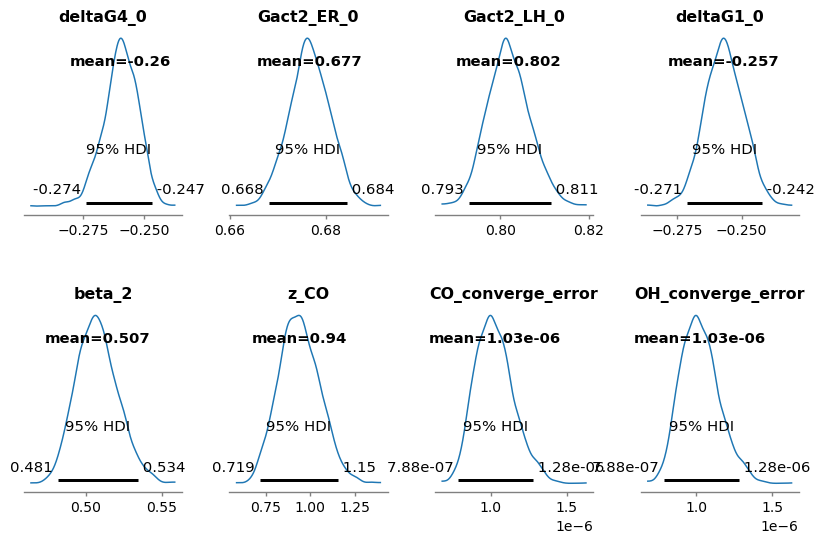

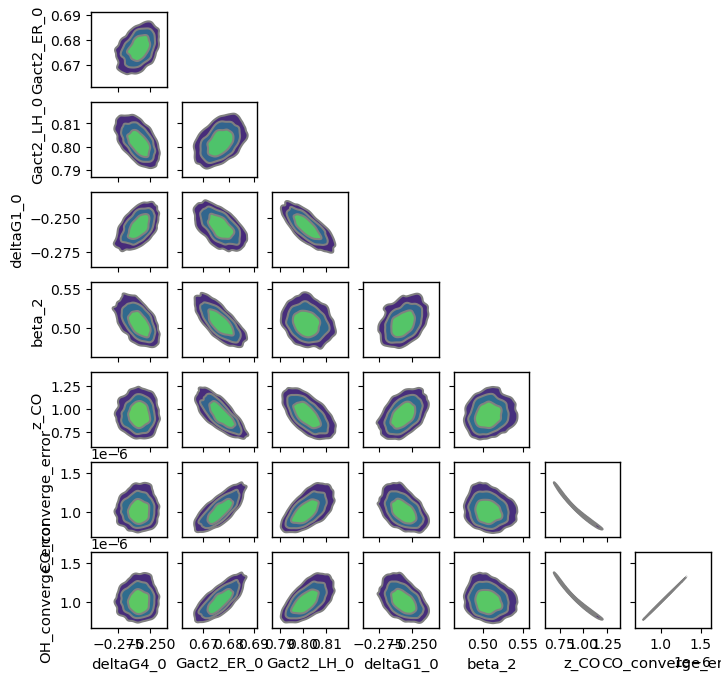

Sampling: [rate]


rate: 0.796


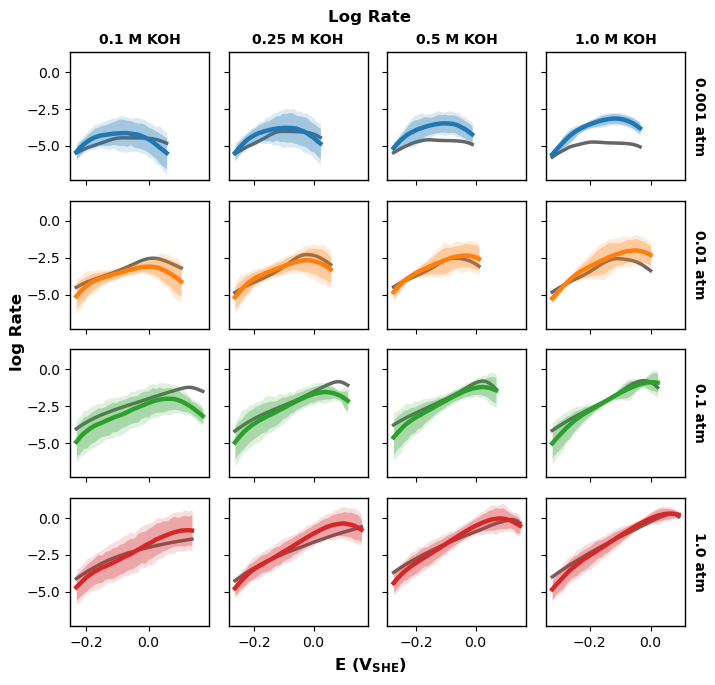

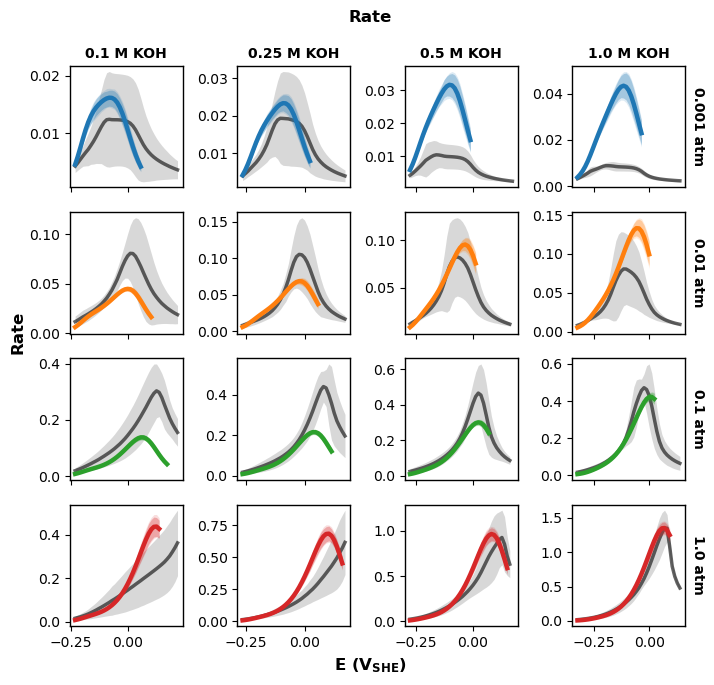

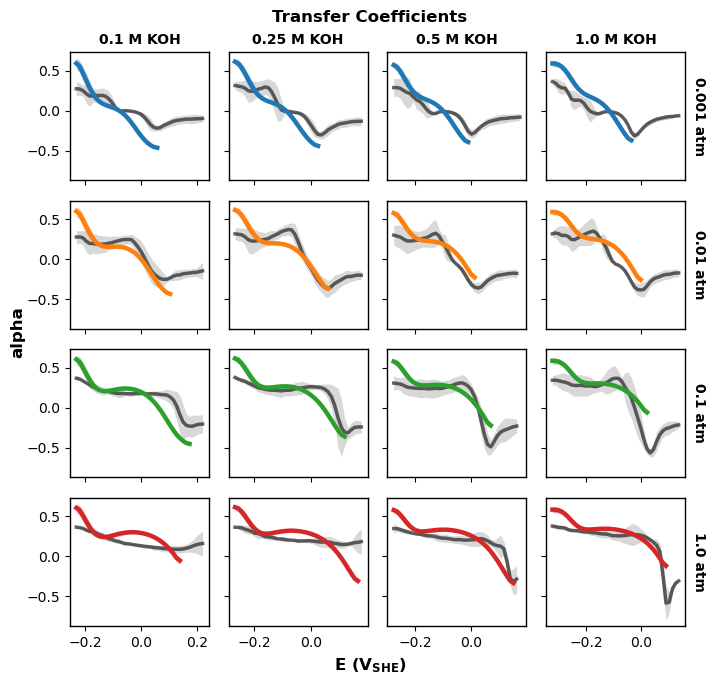

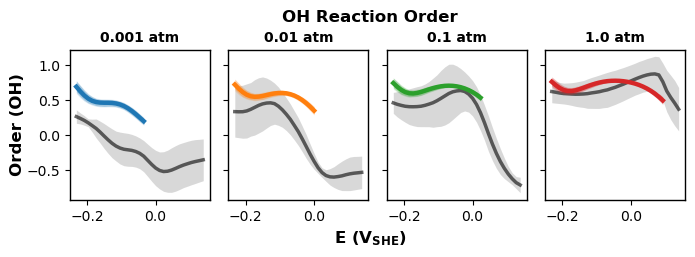

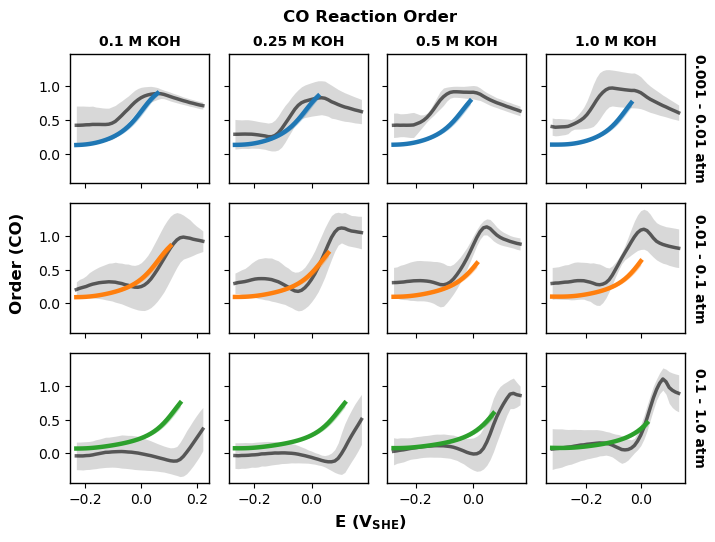

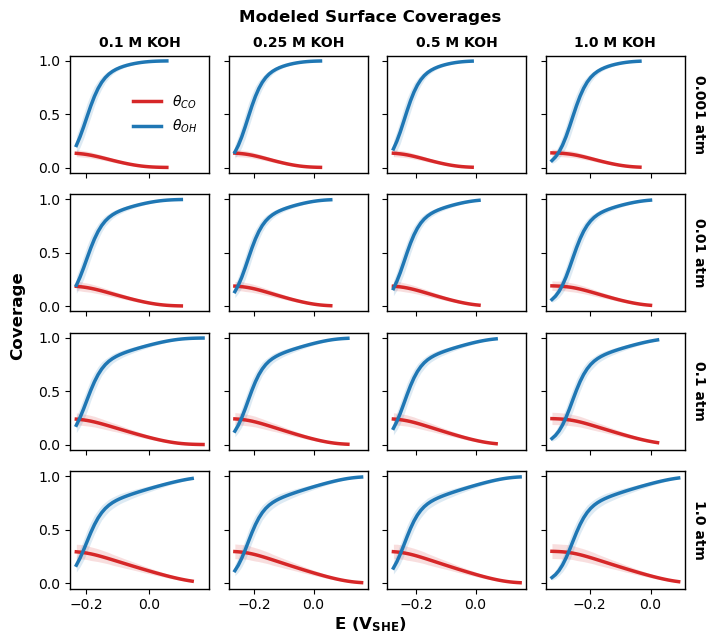

In [8]:
ppc_ER_LH_2_lateral = plot_posteriors(trace_ER_LH_2_lateral, ER_LH_2_lateral, plot_target)
plot_model_fits(trace_ER_LH_2_lateral, ppc_ER_LH_2_lateral); plot_coverages(trace_ER_LH_2_lateral)

# ER 2 3 Lateral

# Full

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.26,15
,3000,0,0.27,15
,3000,0,0.26,15
,231,0,0.00,1023


arviz - WARNING - Array contains NaN-value.
c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo      nan      nan
p_loo         nan        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)        0    0.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)  494  100.0%



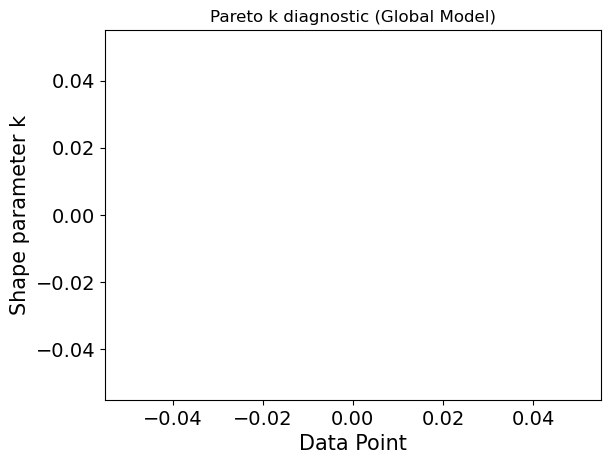

In [9]:
with pm.Model() as full_lateral:
    '''
    1. CO + * <-> CO* (QEA Frumkin)
    2a. CO* + OH- <-> COOH* + (e-) (SSA)
    2b. CO* + OH* <-> COOH* + * (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Irr) (SSA)
    4. OH- + * <-> OH* + (e-) (QEA Frumkin)
    '''
    # Priors 
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.20, sigma=0.10, upper=0.0)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.10)
    deltaG2_ER_0 = pm.Normal('deltaG2_ER_0', mu=-0.469, sigma=0.04)
    beta_2 = pm.TruncatedNormal('beta_2', mu=0.190, sigma=0.02, lower=0.0, upper=1.0)
    beta_3 = pm.TruncatedNormal('beta_3', mu=0.601, sigma=0.04, lower=0.0, upper=1.0)
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.696, sigma=0.01)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.750, sigma=0.01)
    Gact3_0 = pm.TruncatedNormal('Gact3_0', mu=0.609, sigma=0.02, lower=0.0)
    
    z_CO = pm.TruncatedNormal('z_CO', lower=0, mu=0.2, sigma=0.2)
    # z_OH = pm.Normal('z_OH', mu=0.4, sigma=0.2) 
    # z_cross = pm.Normal('z_cross', mu=0.1, sigma=0.2)
    z_cross = 0.0 
    z_CO = 0.0
    z_OH = 0.0

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG2_ER = deltaG2_ER_0 - E_in
    deltaG2_LH = deltaG2_ER_0 - deltaG4_0 # Hess's law
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0 
    Gact3 = Gact3_0 - beta_3*E_in
    
    log_K1_base = -deltaG1/(kb_eV*T) 
    log_K4_base = -deltaG4/(kb_eV*T) 
    log_K2_ER = -deltaG2_ER/(kb_eV*T)
    log_K2_LH = -deltaG2_LH/(kb_eV*T)
    log_prefactor = np.log(kb_J*T/h)
    log_k2_ER = log_prefactor - Gact2_ER/(kb_eV*T)
    log_k2_LH = log_prefactor - Gact2_LH/(kb_eV*T)
    log_k3 = log_prefactor - Gact3/(kb_eV*T)

    log_k2_ER_f = log_k2_ER + np.log(C_KOH_in)
    log_k2_ER_b = log_k2_ER - log_K2_ER
    log_k2_LH_f = log_k2_LH
    log_k2_LH_b = log_k2_LH - log_K2_LH
    log_k3_C = log_k3 + np.log(C_KOH_in)

    # Initial guess
    term_CO_base = log_K1_base + np.log(P_CO_in)
    term_OH_base = log_K4_base + np.log(C_KOH_in)
    shift_COOH_init = log_k2_ER_f - pt.logaddexp(log_k2_ER_b, log_k3_C)
    term_COOH_base = term_CO_base + shift_COOH_init
    zeros = pt.zeros_like(term_CO_base)
    log_theta_init = - pt.logsumexp(pt.stack([zeros, term_CO_base, term_OH_base, term_COOH_base]), axis=0)
    theta_CO_guess = pt.exp(term_CO_base + log_theta_init)
    theta_OH_guess = pt.exp(term_OH_base + log_theta_init)
    theta_COOH_guess = pt.exp(term_COOH_base + log_theta_init)
    
    # Iterative solver setup
    n_iter_steps = 24
    damp_array = pt.as_tensor_variable(np.maximum(0.6 * (0.80 ** np.arange(n_iter_steps)), 0.05))
    
    def frumkin_root_step(damp, theta_CO_prev, theta_OH_prev, theta_COOH_prev, 
                          term_CO_base, term_OH_base, 
                          log_k2_ER_f, log_k2_ER_b, log_k2_LH_f, log_k2_LH_b, log_k3_C, 
                          z_CO, z_OH, z_cross, kb_eV_T, zeros):
        
        theta_prev = pt.maximum(1.0 - theta_CO_prev - theta_OH_prev - theta_COOH_prev, 1e-12)
        penalty_CO = (z_CO * theta_CO_prev + z_cross * theta_OH_prev) / kb_eV_T
        penalty_OH = (z_OH * theta_OH_prev + z_cross * theta_CO_prev) / kb_eV_T
        term_CO_iter = term_CO_base - penalty_CO
        term_OH_iter = term_OH_base - penalty_OH
        
        # Dynamic SSA for COOH including ER and LH pathways
        num_COOH = pt.exp(log_k2_ER_f) + pt.exp(log_k2_LH_f) * theta_OH_prev
        den_COOH = pt.exp(log_k2_ER_b) + pt.exp(log_k2_LH_b) * theta_prev + pt.exp(log_k3_C)
        shift_COOH_iter = pt.log(num_COOH) - pt.log(den_COOH)
        term_COOH_iter = term_CO_iter + shift_COOH_iter 
        
        # Normalize
        log_theta_iter = -pt.logsumexp(pt.stack([zeros, term_CO_iter, term_OH_iter, term_COOH_iter]), axis=0)
        theta_CO_calc = pt.exp(term_CO_iter + log_theta_iter)
        theta_OH_calc = pt.exp(term_OH_iter + log_theta_iter)
        theta_COOH_calc = pt.exp(term_COOH_iter + log_theta_iter)
        
        # Dampened update
        theta_CO_new = damp * theta_CO_calc + (1.0 - damp) * theta_CO_prev
        theta_OH_new = damp * theta_OH_calc + (1.0 - damp) * theta_OH_prev
        theta_COOH_new = damp * theta_COOH_calc + (1.0 - damp) * theta_COOH_prev
        
        return theta_CO_new, theta_OH_new, theta_COOH_new

    theta_CO_seq, theta_OH_seq, theta_COOH_seq = pytensor.scan(
        fn=frumkin_root_step, sequences=[damp_array], outputs_info=[theta_CO_guess, theta_OH_guess, theta_COOH_guess],
        non_sequences=[term_CO_base, term_OH_base, log_k2_ER_f, log_k2_ER_b, log_k2_LH_f, log_k2_LH_b, log_k3_C, 
                       z_CO, z_OH, z_cross, kb_eV * T, zeros], n_steps=n_iter_steps, return_updates=False)
    theta_CO_final = theta_CO_seq[-1]; theta_OH_final = theta_OH_seq[-1]; theta_COOH_final = theta_COOH_seq[-1]
    theta_final = pt.maximum(1.0 - theta_CO_final - theta_OH_final - theta_COOH_final, 1e-12)
    CO_error = pt.max(pt.abs(theta_CO_seq[-1] - theta_CO_seq[-2])); pm.Deterministic('CO_converge_error', CO_error)
    OH_error = pt.max(pt.abs(theta_OH_seq[-1] - theta_OH_seq[-2])); pm.Deterministic('OH_converge_error', OH_error)
    
    term_CO_final = term_CO_base - (z_CO * theta_CO_final + z_cross * theta_OH_final) / (kb_eV * T)
    term_OH_final = term_OH_base - (z_OH * theta_OH_final + z_cross * theta_CO_final) / (kb_eV * T)
    num_COOH_final = pt.exp(log_k2_ER_f) + pt.exp(log_k2_LH_f) * theta_OH_final
    den_COOH_final = pt.exp(log_k2_ER_b) + pt.exp(log_k2_LH_b) * theta_final + pt.exp(log_k3_C)
    shift_COOH_final = pt.log(num_COOH_final) - pt.log(den_COOH_final)
    term_COOH_final = term_CO_final + shift_COOH_final 
    
    log_theta_final = -pt.logsumexp(pt.stack([zeros, term_CO_final, term_OH_final, term_COOH_final]), axis=0) 
    log_theta_CO = term_CO_final + log_theta_final
    log_theta_OH = term_OH_final + log_theta_final
    log_theta_COOH = term_COOH_final + log_theta_final

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_COOH = pm.Deterministic('theta_COOH', pt.exp(log_theta_COOH))

    # Rate expression
    log_rate_model = log_k3_C + log_theta_COOH
    log_rate = observables(log_rate_model)

trace_full_lateral, loo_full_lateral = fit_and_evaluate(full_lateral, target_accept=0.95)

                    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0         -0.360  0.018  -0.395   -0.328      0.001    0.000     882.0    1394.0   1.00
deltaG2_ER_0      -0.574  0.021  -0.611   -0.535      0.000    0.000    2928.0    2206.0   1.00
Gact2_LH_0         0.705  0.008   0.690    0.721      0.000    0.000     447.0     624.0   1.00
Gact2_ER_0         0.760  0.009   0.744    0.775      0.000    0.000    1062.0    1558.0   1.00
z_OH               0.507  0.034   0.447    0.575      0.001    0.001     794.0    1369.0   1.00
deltaG1_0         -0.055  0.007  -0.070   -0.042      0.000    0.000     454.0     636.0   1.00
beta_2             0.228  0.025   0.183    0.277      0.001    0.000     916.0    1392.0   1.00
beta_3             0.422  0.015   0.396    0.451      0.001    0.000     661.0     719.0   1.00
Gact3_0            0.711  0.004   0.704    0.717      0.000    0.000     539.0     637.0   1.00
CO_converge_error  0.000  0.000   0.000 

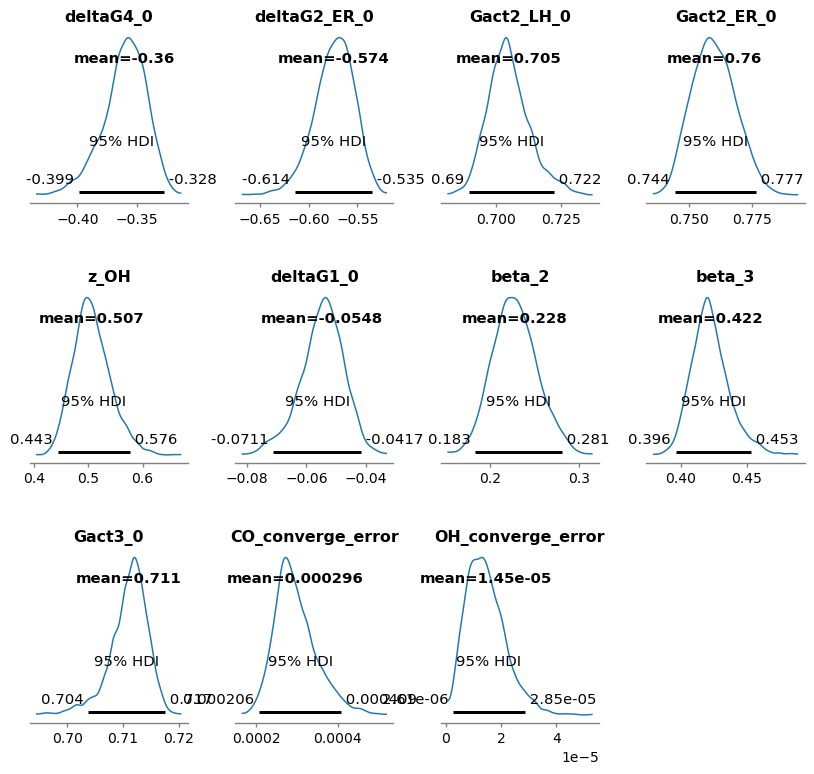

c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\plots\backends\matplotlib\pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


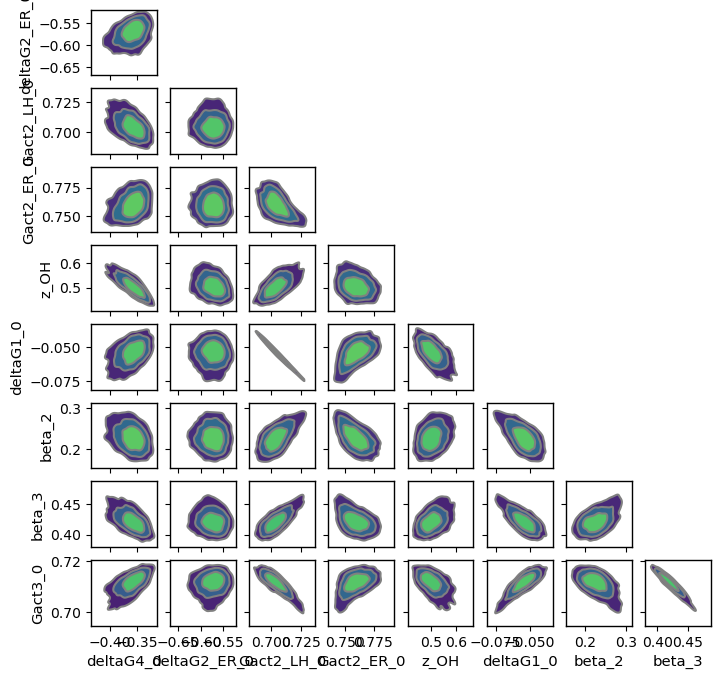

Sampling: [rate]


rate: 0.878


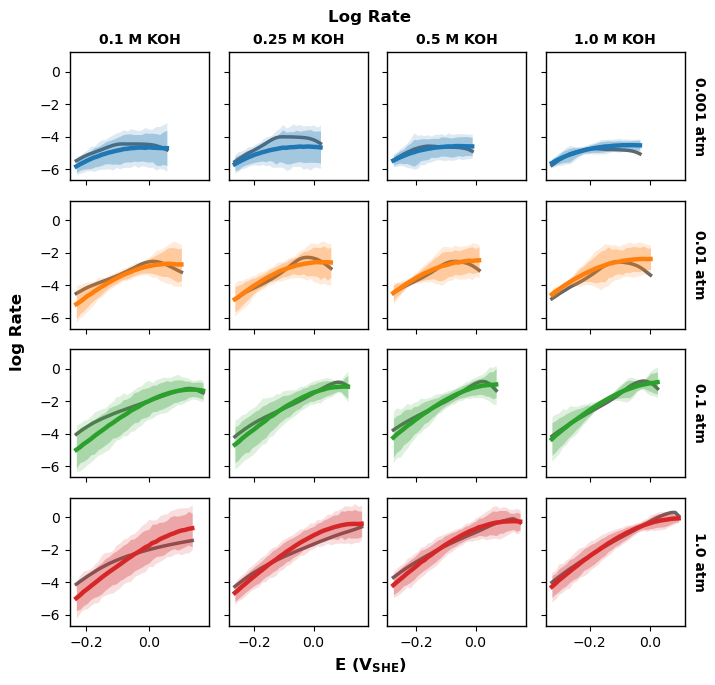

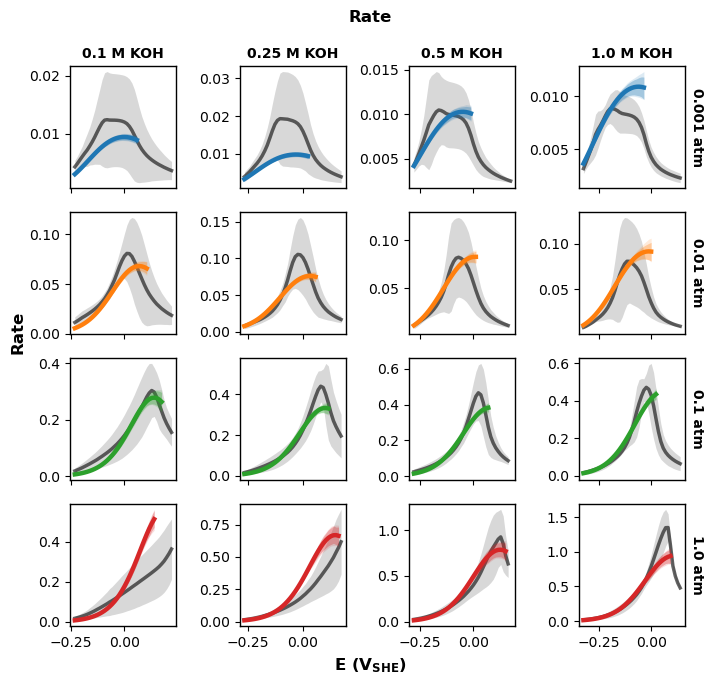

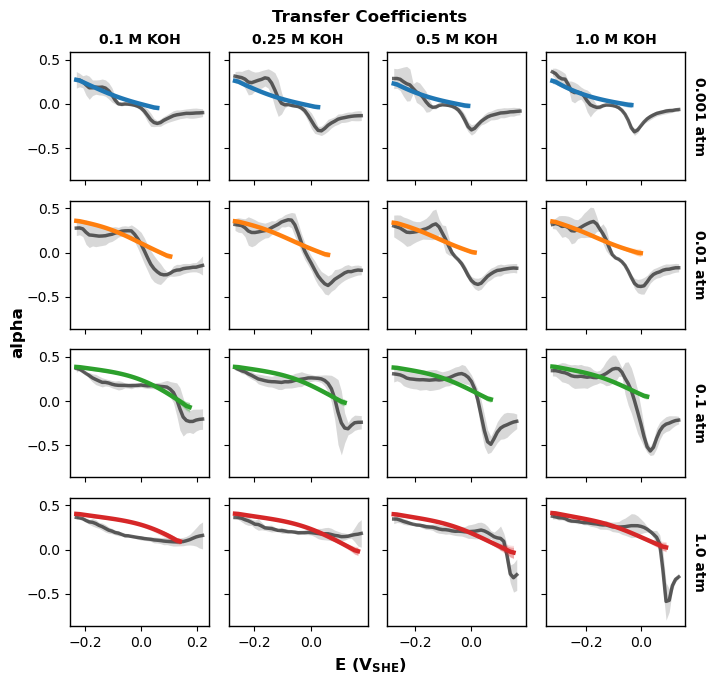

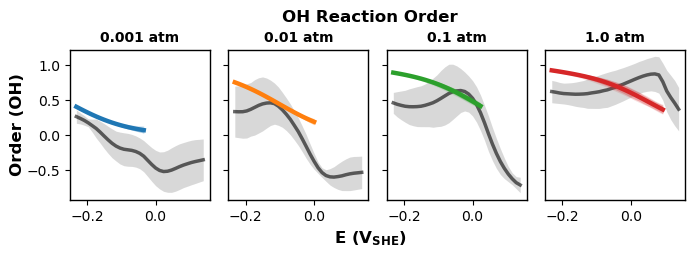

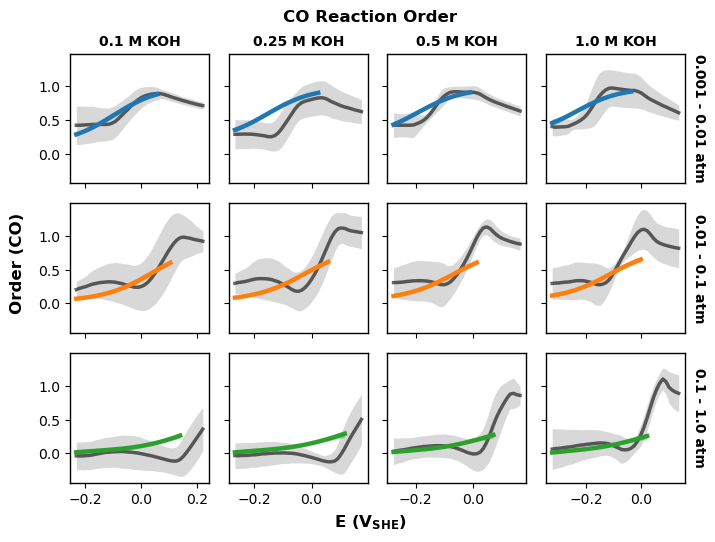

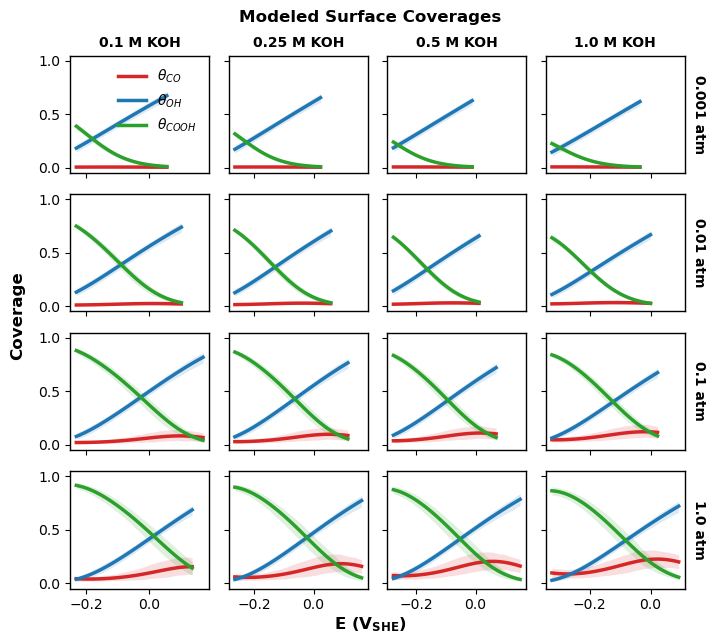

In [ ]:
ppc_full_lateral = plot_posteriors(trace_full_lateral, full_lateral, plot_target)
plot_model_fits(trace_full_lateral, ppc_full_lateral); plot_coverages(trace_full_lateral)

# Comparison

                 rank    elpd_loo      p_loo   elpd_diff    weight         se        dse  warning scale
full_lateral        0 -144.593379  12.312678    0.000000  0.436677  16.669313   0.000000    False   log
ER_LH_2_lateral     1 -147.787723  10.538544    3.194345  0.563323  24.526599  24.482843    False   log
ER_2_3_lateral      2 -447.472370  14.694353  302.878991  0.000000  34.191683  32.336657    False   log


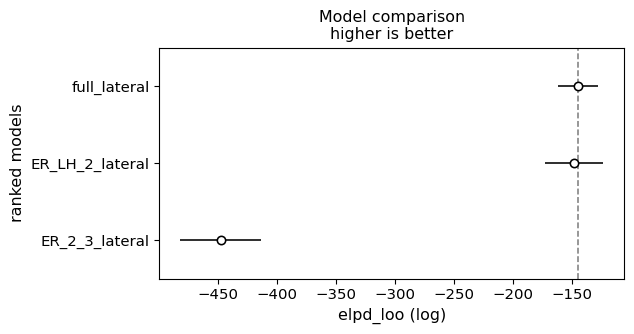

In [ ]:
comparison_dict = {
    "ER_LH_2_lateral": loo_ER_LH_2_lateral,
    # "ER_2_3_lateral": loo_ER_2_3_lateral,
    "full_lateral": loo_full_lateral
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()